# Comparación de Clasificadores

    > The Bayes classifier produces the lowest possible test error rate, called the Bayes error rate. The Bayes error rate is analogous to the irreducible error.

An Introduction to Statistical Learning (ISLP), p. 36.

## 1. Importar librerías necesarias
En esta sección se importan las librerías requeridas para el procesamiento de datos, visualización y modelado estadístico.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

## 2. Generar datos simulados
En este bloque se generan datos sintéticos para dos clases diferentes usando distribuciones normales multivariadas. Esto permite simular un problema de clasificación.

In [18]:
# Fijar semilla para reproducibilidad
np.random.seed(42)

n = 100

# Generar datos para la clase 0
X0 = np.vstack([
    np.random.multivariate_normal(
        mean=[-1.5, 1.0],
        cov=[[0.5, 0.1], [0.1, 0.7]],
        size=n//2
    ),
    np.random.multivariate_normal(
        mean=[-0.5, -1.0],
        cov=[[0.4, -0.1], [-0.1, 0.4]],
        size=n//2
    )
])

# Generar datos para la clase 1
X1 = np.vstack([
    np.random.multivariate_normal(
        mean=[1.2, 1.0],
        cov=[[0.6, -0.2], [-0.2, 0.6]],
        size=n//2
    ),
    np.random.multivariate_normal(
        mean=[1.0, -1.2],
        cov=[[0.5, 0.1], [0.1, 0.5]],
        size=n//2
    )
])

y0 = np.zeros(len(X0))
y1 = np.ones(len(X1))

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

## 2.1 Dividir datos en conjunto de entrenamiento y prueba
Se divide el conjunto de datos en 70% para entrenamiento y 30% para prueba, lo que permite evaluar el desempeño de los modelos en datos no vistos durante el entrenamiento.

In [19]:
# Dividir datos en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"\nDistribución en entrenamiento - Clase 0: {(y_train==0).sum()}, Clase 1: {(y_train==1).sum()}")
print(f"Distribución en prueba - Clase 0: {(y_test==0).sum()}, Clase 1: {(y_test==1).sum()}")

Conjunto de entrenamiento: 140 muestras
Conjunto de prueba: 60 muestras

Distribución en entrenamiento - Clase 0: 70, Clase 1: 70
Distribución en prueba - Clase 0: 30, Clase 1: 30


## 3. Entrenamiento de modelos Gaussian Mixture por clase
Se ajustan modelos de mezcla de gaussianas (GMM) para cada clase de datos, lo que permite modelar la distribución de cada clase de manera flexible.

In [20]:
# Crear y ajustar modelos GMM para cada clase usando datos de entrenamiento
gmm0 = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm1 = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm0.fit(X_train[y_train == 0])
gmm1.fit(X_train[y_train == 1])

# Calcular los priors estimados en el conjunto de entrenamiento
prior0 = np.mean(y_train == 0)
prior1 = np.mean(y_train == 1)

## 4. Crear malla para visualización
Se genera una malla de puntos en el espacio de características para poder visualizar la frontera de decisión del clasificador.

In [23]:
# Definir los límites de la malla basados en datos de entrenamiento
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

## 5. Aplicar la regla Bayesiana para clasificación
Se calcula la probabilidad logarítmica de pertenencia a cada clase para cada punto de la malla y se determina la clase óptima según la regla de Bayes.

In [25]:
# Calcular log-probabilidades para cada clase
log_p0 = gmm0.score_samples(grid) + np.log(prior0)
log_p1 = gmm1.score_samples(grid) + np.log(prior1)

decision = (log_p1 > log_p0).astype(int)
decision = decision.reshape(xx.shape)

boundary = (log_p1 - log_p0).reshape(xx.shape)

## 6. Visualizar la frontera de decisión y los datos
Se grafica la frontera de decisión estimada por el clasificador Bayesiano junto con los datos simulados de ambas clases.

/tmp/ipykernel_21677/3122531771.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


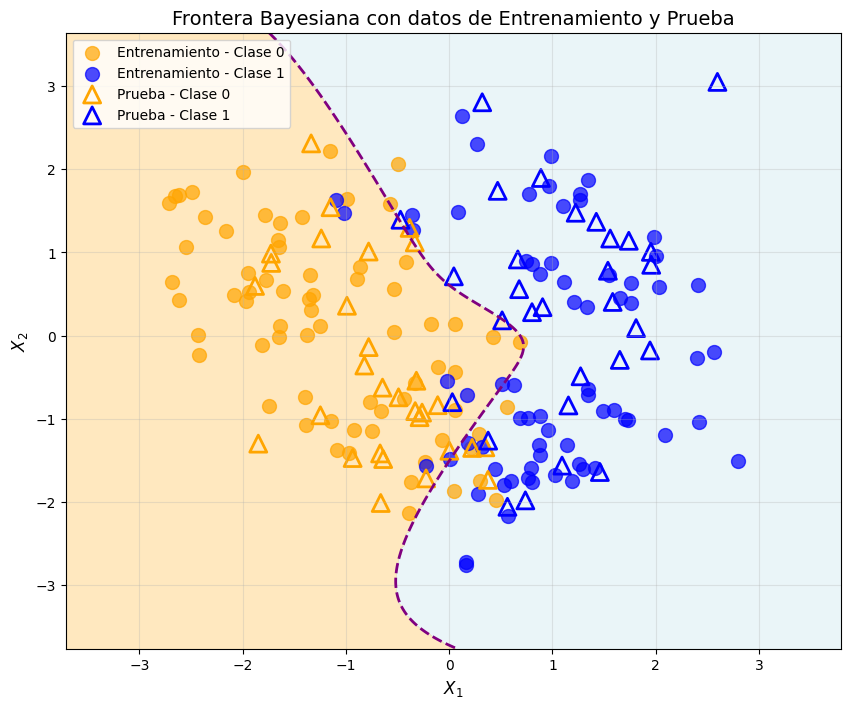

In [26]:
plt.figure(figsize=(10, 8))

plt.contourf(
    xx, yy,
    decision,
    levels=[-0.5, 0.5, 1.5],
    colors=["orange", "lightblue"],
    alpha=0.25
)

plt.contour(
    xx, yy,
    boundary,
    levels=[0],
    colors='purple',
    linestyles='--',
    linewidths=2,
    label='Frontera Bayesiana'
)

# Datos de entrenamiento
plt.scatter(
    X_train[y_train==0,0],
    X_train[y_train==0,1],
    facecolors='orange',
    edgecolors='orange',
    s=100,
    alpha=0.7,
    label='Entrenamiento - Clase 0'
)

plt.scatter(
    X_train[y_train==1,0],
    X_train[y_train==1,1],
    facecolors='blue',
    edgecolors='blue',
    s=100,
    alpha=0.7,
    label='Entrenamiento - Clase 1'
)

# Datos de prueba (con marcadores diferentes)
plt.scatter(
    X_test[y_test==0,0],
    X_test[y_test==0,1],
    facecolors='none',
    edgecolors='orange',
    s=150,
    marker='^',
    linewidths=2,
    label='Prueba - Clase 0'
)

plt.scatter(
    X_test[y_test==1,0],
    X_test[y_test==1,1],
    facecolors='none',
    edgecolors='blue',
    s=150,
    marker='^',
    linewidths=2,
    label='Prueba - Clase 1'
)

plt.xlabel("$X_1$", fontsize=12)
plt.ylabel("$X_2$", fontsize=12)
plt.title("Frontera Bayesiana con datos de Entrenamiento y Prueba", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

## 7. Comparación con clasificador K-Nearest Neighbors (KNN)
A continuación se entrena un clasificador KNN y se compara su frontera de decisión con la frontera Bayesiana obtenida con GMM.

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Entrenar clasificador KNN con k=5 usando datos de entrenamiento
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Obtener predicciones en la malla
knn_decision = knn.predict(grid)
knn_decision = knn_decision.reshape(xx.shape)

## 8. Visualizar y comparar fronteras de decisión
Se visualizan lado a lado las fronteras de decisión del clasificador Bayesiano (GMM) y el clasificador KNN.

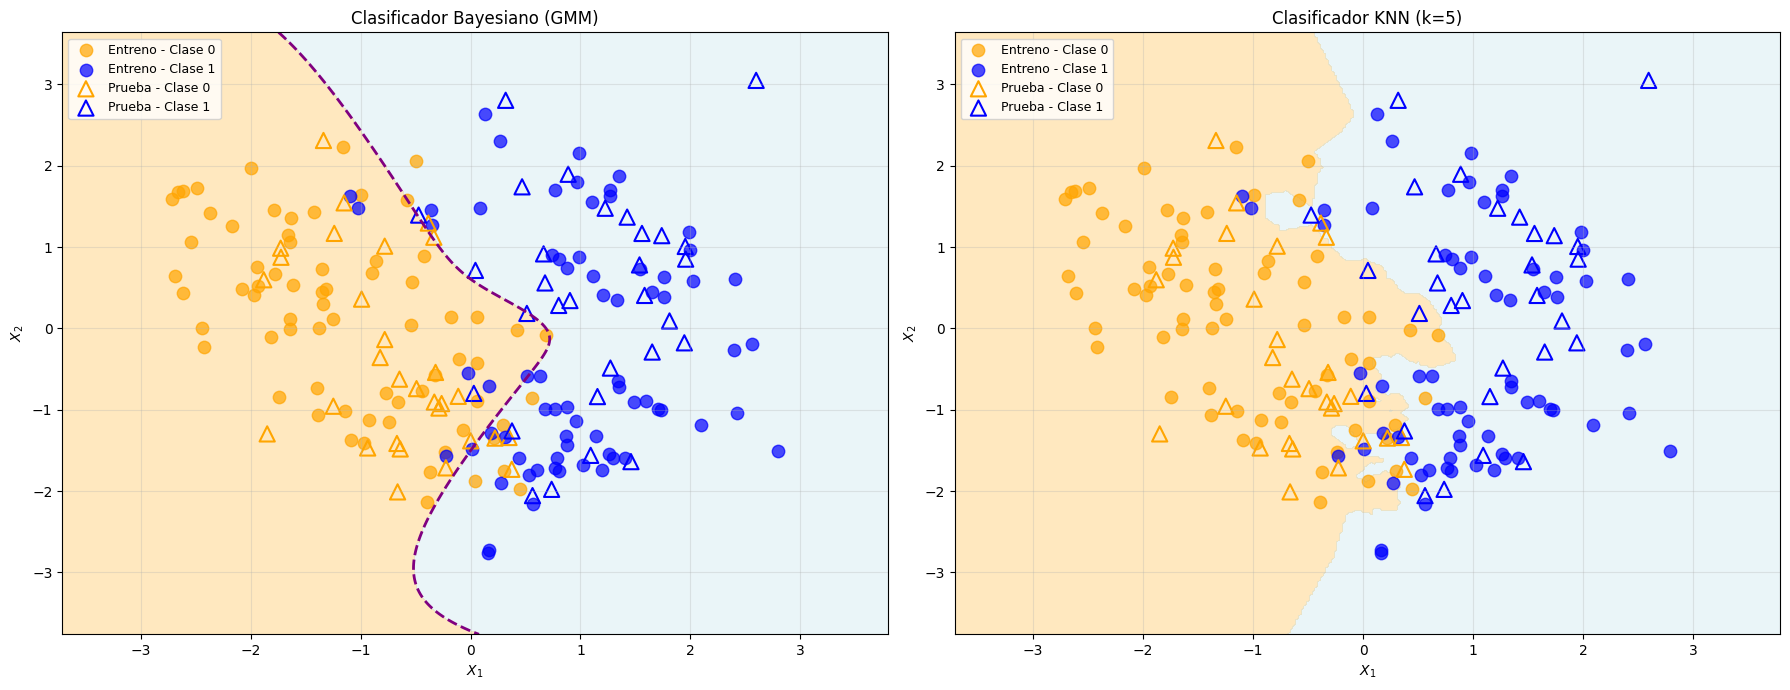

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Clasificador Bayesiano (GMM)
ax1 = axes[0]
ax1.contourf(
    xx, yy,
    decision,
    levels=[-0.5, 0.5, 1.5],
    colors=["orange", "lightblue"],
    alpha=0.25
)

ax1.contour(
    xx, yy,
    boundary,
    levels=[0],
    colors='purple',
    linestyles='--',
    linewidths=2
)

# Datos de entrenamiento
ax1.scatter(
    X_train[y_train==0,0],
    X_train[y_train==0,1],
    facecolors='orange',
    edgecolors='orange',
    s=80,
    alpha=0.7,
    label='Entreno - Clase 0'
)

ax1.scatter(
    X_train[y_train==1,0],
    X_train[y_train==1,1],
    facecolors='blue',
    edgecolors='blue',
    s=80,
    alpha=0.7,
    label='Entreno - Clase 1'
)

# Datos de prueba
ax1.scatter(
    X_test[y_test==0,0],
    X_test[y_test==0,1],
    facecolors='none',
    edgecolors='orange',
    s=120,
    marker='^',
    linewidths=1.5,
    label='Prueba - Clase 0'
)

ax1.scatter(
    X_test[y_test==1,0],
    X_test[y_test==1,1],
    facecolors='none',
    edgecolors='blue',
    s=120,
    marker='^',
    linewidths=1.5,
    label='Prueba - Clase 1'
)

ax1.set_xlabel("$X_1$")
ax1.set_ylabel("$X_2$")
ax1.set_title("Clasificador Bayesiano (GMM)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Gráfico 2: Clasificador KNN
ax2 = axes[1]
ax2.contourf(
    xx, yy,
    knn_decision,
    levels=[-0.5, 0.5, 1.5],
    colors=["orange", "lightblue"],
    alpha=0.25
)

# Datos de entrenamiento
ax2.scatter(
    X_train[y_train==0,0],
    X_train[y_train==0,1],
    facecolors='orange',
    edgecolors='orange',
    s=80,
    alpha=0.7,
    label='Entreno - Clase 0'
)

ax2.scatter(
    X_train[y_train==1,0],
    X_train[y_train==1,1],
    facecolors='blue',
    edgecolors='blue',
    s=80,
    alpha=0.7,
    label='Entreno - Clase 1'
)

# Datos de prueba
ax2.scatter(
    X_test[y_test==0,0],
    X_test[y_test==0,1],
    facecolors='none',
    edgecolors='orange',
    s=120,
    marker='^',
    linewidths=1.5,
    label='Prueba - Clase 0'
)

ax2.scatter(
    X_test[y_test==1,0],
    X_test[y_test==1,1],
    facecolors='none',
    edgecolors='blue',
    s=120,
    marker='^',
    linewidths=1.5,
    label='Prueba - Clase 1'
)

ax2.set_xlabel("$X_1$")
ax2.set_ylabel("$X_2$")
ax2.set_title("Clasificador KNN (k=5)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluar y comparar desempeño de ambos clasificadores
Se calcula la precisión (accuracy) de ambos modelos en los datos de entrenamiento.

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Obtener predicciones para ambos clasificadores en entrenamiento y prueba
# Bayesiano en entrenamiento
log_p0_train = gmm0.score_samples(X_train) + np.log(prior0)
log_p1_train = gmm1.score_samples(X_train) + np.log(prior1)
gmm_pred_train = (log_p1_train > log_p0_train).astype(int)

# Bayesiano en prueba
log_p0_test = gmm0.score_samples(X_test) + np.log(prior0)
log_p1_test = gmm1.score_samples(X_test) + np.log(prior1)
gmm_pred_test = (log_p1_test > log_p0_test).astype(int)

# KNN en entrenamiento y prueba
knn_pred_train = knn.predict(X_train)
knn_pred_test = knn.predict(X_test)

# Calcular precisión
gmm_accuracy_train = accuracy_score(y_train, gmm_pred_train)
gmm_accuracy_test = accuracy_score(y_test, gmm_pred_test)
knn_accuracy_train = accuracy_score(y_train, knn_pred_train)
knn_accuracy_test = accuracy_score(y_test, knn_pred_test)

print("=" * 70)
print("COMPARACIÓN DE CLASIFICADORES - ENTRENAMIENTO vs PRUEBA")
print("=" * 70)
print(f"\nClasificador Bayesiano (GMM):")
print(f"  Precisión en Entrenamiento: {gmm_accuracy_train:.4f}")
print(f"  Precisión en Prueba:        {gmm_accuracy_test:.4f}")
print(f"  Diferencia (Overfitting):   {gmm_accuracy_train - gmm_accuracy_test:.4f}")

print(f"\nClasificador KNN (k=5):")
print(f"  Precisión en Entrenamiento: {knn_accuracy_train:.4f}")
print(f"  Precisión en Prueba:        {knn_accuracy_test:.4f}")
print(f"  Diferencia (Overfitting):   {knn_accuracy_train - knn_accuracy_test:.4f}")

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSIÓN - CLASIFICADOR BAYESIANO (ENTRENAMIENTO)")
print("=" * 70)
print(confusion_matrix(y_train, gmm_pred_train))

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSIÓN - CLASIFICADOR BAYESIANO (PRUEBA)")
print("=" * 70)
print(confusion_matrix(y_test, gmm_pred_test))

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSIÓN - CLASIFICADOR KNN (ENTRENAMIENTO)")
print("=" * 70)
print(confusion_matrix(y_train, knn_pred_train))

print("\n" + "=" * 70)
print("MATRIZ DE CONFUSIÓN - CLASIFICADOR KNN (PRUEBA)")
print("=" * 70)
print(confusion_matrix(y_test, knn_pred_test))

COMPARACIÓN DE CLASIFICADORES - ENTRENAMIENTO vs PRUEBA

Clasificador Bayesiano (GMM):
  Precisión en Entrenamiento: 0.9000
  Precisión en Prueba:        0.8833
  Diferencia (Overfitting):   0.0167

Clasificador KNN (k=5):
  Precisión en Entrenamiento: 0.9071
  Precisión en Prueba:        0.8667
  Diferencia (Overfitting):   0.0405

MATRIZ DE CONFUSIÓN - CLASIFICADOR BAYESIANO (ENTRENAMIENTO)
[[63  7]
 [ 7 63]]

MATRIZ DE CONFUSIÓN - CLASIFICADOR BAYESIANO (PRUEBA)
[[25  5]
 [ 2 28]]

MATRIZ DE CONFUSIÓN - CLASIFICADOR KNN (ENTRENAMIENTO)
[[64  6]
 [ 7 63]]

MATRIZ DE CONFUSIÓN - CLASIFICADOR KNN (PRUEBA)
[[25  5]
 [ 3 27]]


In [30]:
print("\n" + "=" * 70)
print("REPORTE DE CLASIFICACIÓN - BAYESIANO (ENTRENAMIENTO)")
print("=" * 70)
print(classification_report(y_train, gmm_pred_train, target_names=['Clase 0', 'Clase 1']))

print("\n" + "=" * 70)
print("REPORTE DE CLASIFICACIÓN - BAYESIANO (PRUEBA)")
print("=" * 70)
print(classification_report(y_test, gmm_pred_test, target_names=['Clase 0', 'Clase 1']))

print("\n" + "=" * 70)
print("REPORTE DE CLASIFICACIÓN - KNN (ENTRENAMIENTO)")
print("=" * 70)
print(classification_report(y_train, knn_pred_train, target_names=['Clase 0', 'Clase 1']))

print("\n" + "=" * 70)
print("REPORTE DE CLASIFICACIÓN - KNN (PRUEBA)")
print("=" * 70)
print(classification_report(y_test, knn_pred_test, target_names=['Clase 0', 'Clase 1']))


REPORTE DE CLASIFICACIÓN - BAYESIANO (ENTRENAMIENTO)
              precision    recall  f1-score   support

     Clase 0       0.90      0.90      0.90        70
     Clase 1       0.90      0.90      0.90        70

    accuracy                           0.90       140
   macro avg       0.90      0.90      0.90       140
weighted avg       0.90      0.90      0.90       140


REPORTE DE CLASIFICACIÓN - BAYESIANO (PRUEBA)
              precision    recall  f1-score   support

     Clase 0       0.93      0.83      0.88        30
     Clase 1       0.85      0.93      0.89        30

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60


REPORTE DE CLASIFICACIÓN - KNN (ENTRENAMIENTO)
              precision    recall  f1-score   support

     Clase 0       0.90      0.91      0.91        70
     Clase 1       0.91      0.90      0.91        70

    accuracy                     